In [ ]:
import pandas as pd

file_path = "/application_train.csv"

# Load dataset
df = pd.read_csv(file_path)

# Dataset shape
print("="*80)
print("DATASET SUMMARY")
print("="*80)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

# Column details
print("\n" + "="*80)
print("COLUMN DETAILS")
print("="*80)

column_details = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

print(column_details.to_string(index=False))

# Display first few rows
print("\n" + "="*80)
print("FIRST 5 ROWS")
print("="*80)

display(df.head())

DATASET SUMMARY
Rows    : 58228
Columns : 122

COLUMN DETAILS
                 Column Name Data Type  Missing Values  Unique Values
                  SK_ID_CURR     int64               0          58228
                      TARGET     int64               0              2
          NAME_CONTRACT_TYPE    object               0              2
                 CODE_GENDER    object               0              3
                FLAG_OWN_CAR    object               0              2
             FLAG_OWN_REALTY    object               0              2
                CNT_CHILDREN     int64               0             11
            AMT_INCOME_TOTAL   float64               0            885
                  AMT_CREDIT   float64               0           3579
                 AMT_ANNUITY   float64               4           9249
             AMT_GOODS_PRICE   float64              45            537
             NAME_TYPE_SUITE    object             228              7
            NAME_INCOME_TYPE

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# EXP 2 - Aim: Data Profiling, Cleaning & Feature Engineering

In [ ]:
# Install ydata-profiling (Pandas Profiling)
!pip install -q ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.0 MB/s eta 0:00:00


In [ ]:
# Import libraries
import pandas as pd
from ydata_profiling import ProfileReport

/tmp/ipykernel_816/3467753869.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
# Load dataset
# Replace 'your_file.csv' with your dataset
df = pd.read_csv('/application_train.csv')

# Display first few rows
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:


# Generate a faster profiling report
profile = ProfileReport(
    df,
    title="Pandas Profiling Report",
    explorative=True,
    minimal=True,  # Speeds up report generation
    correlations={
        "pearson": {"calculate": False},
        "spearman": {"calculate": False},
        "kendall": {"calculate": False},
        "phi_k": {"calculate": False},
        "cramers": {"calculate": False},
        "auto": {"calculate": False},
    },
)

# Display report in Colab
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Count missing values in each column
print(df.isnull().sum())

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64


In [ ]:
# Fill missing values in categorical columns with the mode
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Fill missing values with the mode
for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
print("Duplicates before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDataset Shape:", df.shape)

Missing values after cleaning:
SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 122, dtype: int64

Dataset Shape: (307511, 122)


In [ ]:
!pip install -q seaborn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (307511, 122)

Missing Values:
 SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 122, dtype: int64


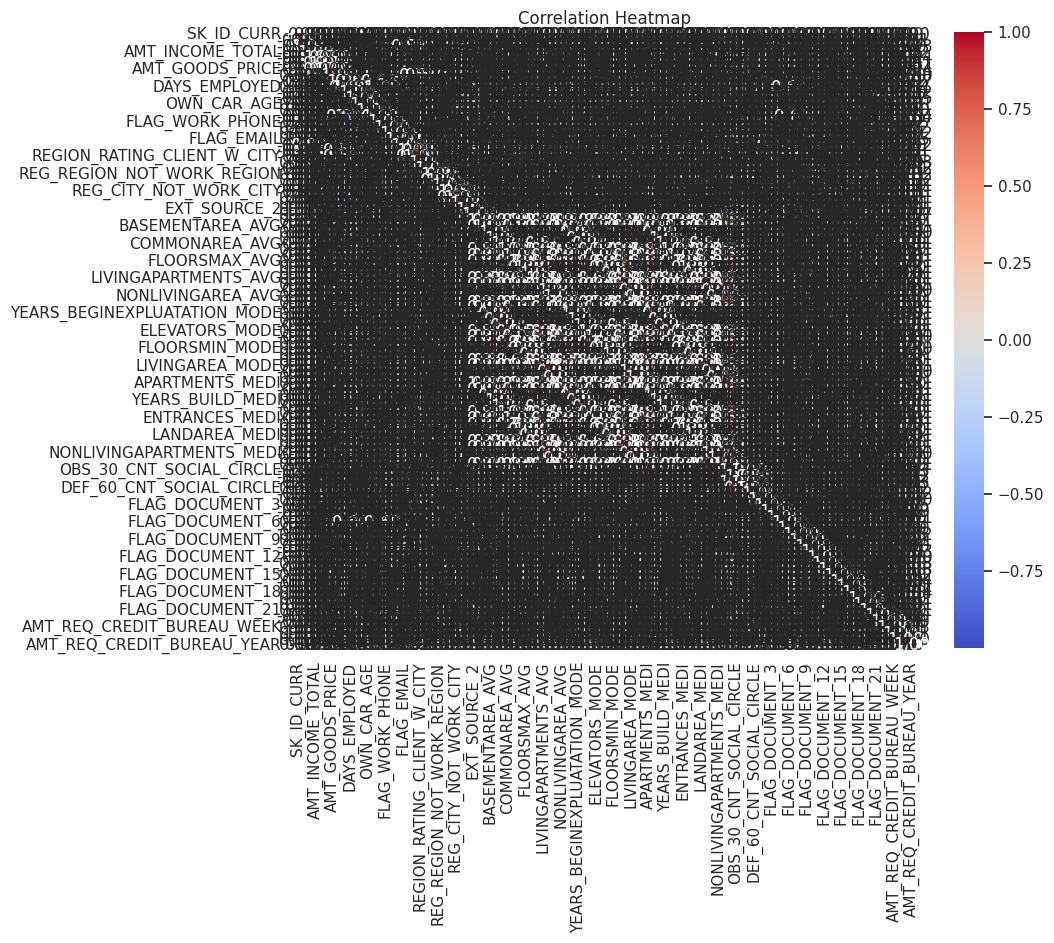

In [ ]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

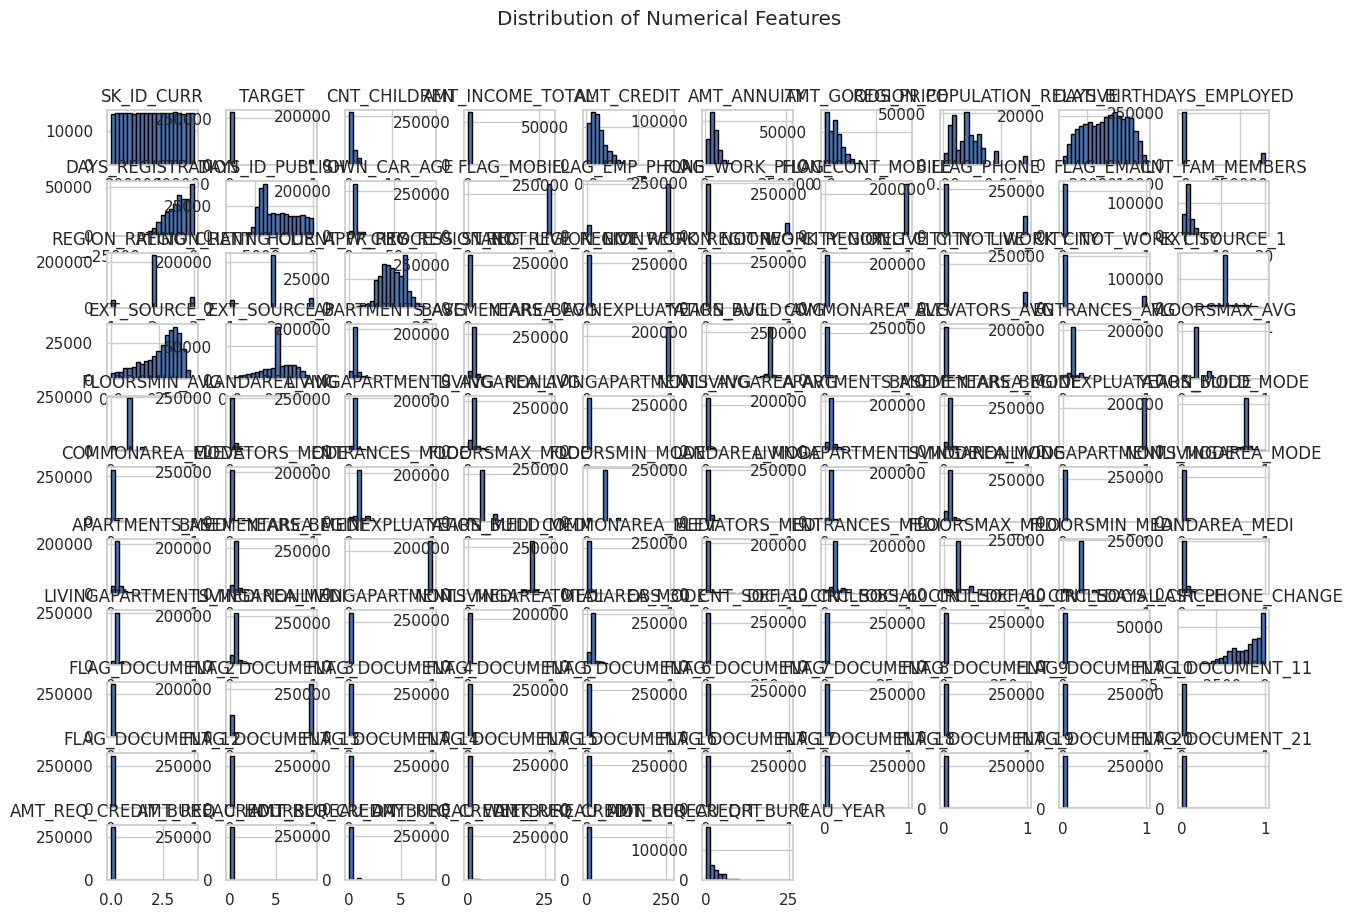

In [ ]:
num_cols = df.select_dtypes(include='number').columns

df[num_cols].hist(
    figsize=(15,10),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features")
plt.show()

Dataset Shape: (307511, 122)

Missing Values:
 SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 122, dtype: int64

Duplicates: 0


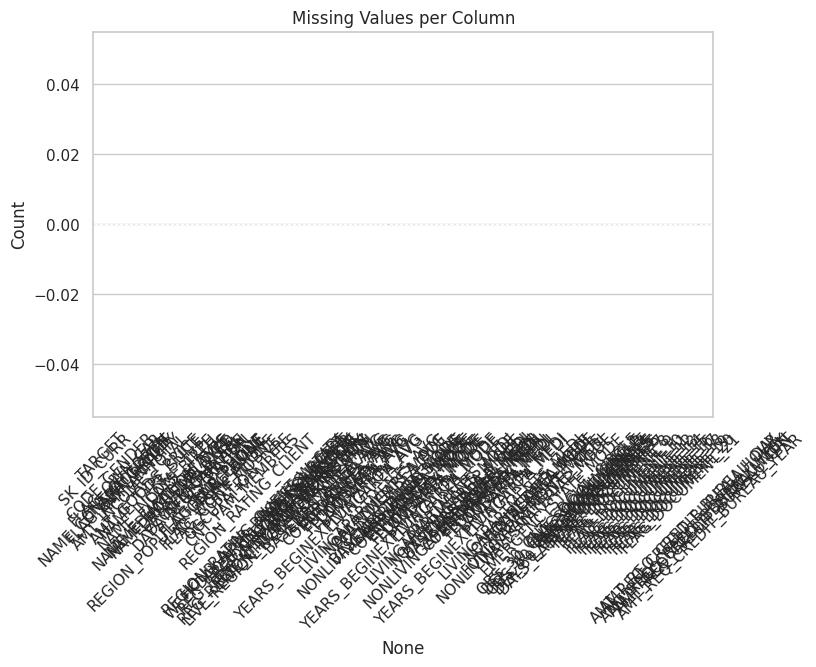

In [ ]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

plt.figure(figsize=(8,5))
sns.barplot(
    x=df.isnull().sum().index,
    y=df.isnull().sum().values,
    color="steelblue"
)

plt.xticks(rotation=45)
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.show()

In [ ]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (307511, 122)

Missing Values:
 SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
Length: 122, dtype: int64


In [ ]:
print(df.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELE

In [ ]:
import pandas as pd
import numpy as np

# Load your dataset
df = pd.read_csv('/application_train.csv')  # adjust path/filename

print("Original shape:", df.shape)

# -----------------------------------------------------
# 1. Drop pure identifier columns (no predictive value)
# -----------------------------------------------------
id_cols = ['SK_ID_CURR']
df = df.drop(columns=[c for c in id_cols if c in df.columns])

# -----------------------------------------------------
# 2. Drop columns with near-zero variance (constant/near-constant)
#    e.g. FLAG_MOBIL is almost always 1
# -----------------------------------------------------
def get_low_variance_cols(data, threshold=0.99):
    low_var_cols = []
    for col in data.columns:
        if data[col].dtype != 'object':
            top_freq = data[col].value_counts(normalize=True, dropna=False).values
            if len(top_freq) > 0 and top_freq[0] > threshold:
                low_var_cols.append(col)
    return low_var_cols

low_var_cols = get_low_variance_cols(df, threshold=0.99)
print("Low variance columns:", low_var_cols)
df = df.drop(columns=low_var_cols)

# -----------------------------------------------------
# 3. Drop columns with excessive missing values
#    (common threshold: >50-60% missing)
# -----------------------------------------------------
missing_pct = df.isnull().mean() * 100
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()
print("High missing columns (>50%):", high_missing_cols)
df = df.drop(columns=high_missing_cols)

# -----------------------------------------------------
# 4. Drop highly correlated numeric columns (redundant info)
#    Keep one from each highly correlated pair (>0.9 correlation)
# -----------------------------------------------------
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.9)]
print("Highly correlated columns dropped:", high_corr_cols)
df = df.drop(columns=high_corr_cols)

# -----------------------------------------------------
# 5. Final check
# -----------------------------------------------------
print("Final shape:", df.shape)
print("\nRemaining columns:\n", df.columns.tolist())

# Save cleaned dataset
df.to_csv('application_train_cleaned.csv', index=False)

Original shape: (307511, 122)
Low variance columns: ['FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']
High missing columns (>50%): ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 

In [ ]:
from google.colab import files

# Save the cleaned dataframe to CSV (if not already saved)
df.to_csv('application_train_cleaned.csv', index=False)

# Trigger download to your local machine
files.download('application_train_cleaned.csv')

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('application_train_cleaned.csv')

# -----------------------------------------------------
# 1. Basic shape & structure check
# -----------------------------------------------------
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes.value_counts())

# -----------------------------------------------------
# 2. Missing values summary
# -----------------------------------------------------
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print("\nColumns with missing values:\n", missing_summary)

# -----------------------------------------------------
# 3. Duplicate rows check
# -----------------------------------------------------
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")

# -----------------------------------------------------
# 4. Target variable distribution (class imbalance check)
# -----------------------------------------------------
if 'TARGET' in df.columns:
    print("\nTARGET distribution:\n", df['TARGET'].value_counts(normalize=True) * 100)

# -----------------------------------------------------
# 5. Check for constant columns (leftover from cleaning)
# -----------------------------------------------------
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
print("\nConstant columns (should be empty):", constant_cols)

# -----------------------------------------------------
# 6. Numeric columns - basic stats & outlier check (IQR method)
# -----------------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumeric summary stats:\n", df[numeric_cols].describe().T)

outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    if outliers > 0:
        outlier_summary[col] = outliers

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['outlier_count'])
outlier_df = outlier_df.sort_values('outlier_count', ascending=False)
print("\nOutlier counts per numeric column (IQR method):\n", outlier_df.head(20))

# -----------------------------------------------------
# 7. Categorical columns - check cardinality & unexpected values
# -----------------------------------------------------
cat_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical column cardinality:")
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# -----------------------------------------------------
# 8. Sanity checks on known domain constraints (Home Credit specific)
# -----------------------------------------------------
issues = []

if 'AMT_INCOME_TOTAL' in df.columns and (df['AMT_INCOME_TOTAL'] < 0).any():
    issues.append("Negative income values found")

if 'AMT_CREDIT' in df.columns and (df['AMT_CREDIT'] <= 0).any():
    issues.append("Zero or negative credit amount found")

if 'DAYS_BIRTH' in df.columns and (df['DAYS_BIRTH'] > 0).any():
    issues.append("DAYS_BIRTH has positive values (should be negative, as days before application)")

if 'DAYS_EMPLOYED' in df.columns:
    anomaly_365243 = (df['DAYS_EMPLOYED'] == 365243).sum()
    if anomaly_365243 > 0:
        issues.append(f"DAYS_EMPLOYED has {anomaly_365243} rows with placeholder value 365243 (known anomaly in this dataset)")

if 'CNT_CHILDREN' in df.columns and (df['CNT_CHILDREN'] < 0).any():
    issues.append("Negative CNT_CHILDREN values found")

print("\nDomain-specific issues found:")
for issue in issues:
    print(" -", issue)
if not issues:
    print(" - None")

# -----------------------------------------------------
# 9. Final validation report
# -----------------------------------------------------
print("\n=== VALIDATION SUMMARY ===")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Duplicate rows: {dup_count}")
print(f"Columns with missing values: {(missing_summary.shape[0])}")
print(f"Constant columns: {len(constant_cols)}")
print(f"Domain issues flagged: {len(issues)}")

In [ ]:
# Install Great Expectations
!pip install great_expectations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.5 MB/s eta 0:00:00


In [ ]:
import great_expectations as gx
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv('application_train_cleaned.csv')

# Create a GX context (ephemeral - in-memory, good for Colab)
context = gx.get_context()

# Connect to the pandas dataframe
data_source = context.data_sources.add_pandas(name="pandas_source")
data_asset = data_source.add_dataframe_asset(name="credit_data")

batch_definition = data_asset.add_batch_definition_whole_dataframe("batch_def")
batch = batch_definition.get_batch(batch_parameters={"dataframe": df})

In [6]:
# -----------------------------------------------------
# Create an Expectation Suite
# -----------------------------------------------------
suite = context.suites.add(gx.ExpectationSuite(name="credit_risk_suite"))

import great_expectations.expectations as gxe

# 1. Table-level expectations
suite.add_expectation(gxe.ExpectTableRowCountToBeBetween(min_value=1000, max_value=1000000))
suite.add_expectation(gxe.ExpectTableColumnCountToBeBetween(min_value=1))

# 2. TARGET column checks
suite.add_expectation(gxe.ExpectColumnToExist(column="TARGET"))
suite.add_expectation(gxe.ExpectColumnValuesToNotBeNull(column="TARGET"))
suite.add_expectation(gxe.ExpectColumnDistinctValuesToBeInSet(column="TARGET", value_set=[0, 1]))

# 3. Income / credit amount checks
suite.add_expectation(gxe.ExpectColumnValuesToBeBetween(column="AMT_INCOME_TOTAL", min_value=0, strict_min=True))
suite.add_expectation(gxe.ExpectColumnValuesToBeBetween(column="AMT_CREDIT", min_value=0, strict_min=True))

if "AMT_ANNUITY" in df.columns:
    suite.add_expectation(gxe.ExpectColumnValuesToBeBetween(column="AMT_ANNUITY", min_value=0))

# 4. CNT_CHILDREN sanity check
suite.add_expectation(gxe.ExpectColumnValuesToBeBetween(column="CNT_CHILDREN", min_value=0, max_value=20))

# 5. DAYS_BIRTH should always be negative (days before application)
suite.add_expectation(gxe.ExpectColumnValuesToBeBetween(column="DAYS_BIRTH", min_value=-40000, max_value=0))

# 6. CODE_GENDER categorical check
if "CODE_GENDER" in df.columns:
    suite.add_expectation(gxe.ExpectColumnDistinctValuesToBeInSet(
        column="CODE_GENDER", value_set=["M", "F", "XNA"]
    ))

# 7. No fully duplicated rows
suite.add_expectation(gxe.ExpectCompoundColumnsToBeUnique(column_list=list(df.columns)))

# 8. Uniqueness of primary key (if not dropped)
if "SK_ID_CURR" in df.columns:
    suite.add_expectation(gxe.ExpectColumnValuesToBeUnique(column="SK_ID_CURR"))

NameError: name 'context' is not defined

In [ ]:
# -----------------------------------------------------
# Run validation
# -----------------------------------------------------
validation_result = batch.validate(suite)

print("Overall success:", validation_result.success)
print("\nDetailed results:")
for result in validation_result.results:
    status = "✅ PASSED" if result.success else "❌ FAILED"
    expectation_type = result.expectation_config.type
    column = result.expectation_config.kwargs.get("column", "N/A")
    print(f"{status} | {expectation_type} | column: {column}")

In [5]:
# -----------------------------------------------------
# Get a readable summary report
# -----------------------------------------------------
total = len(validation_result.results)
passed = sum(r.success for r in validation_result.results)
failed = total - passed

print(f"\n=== GREAT EXPECTATIONS SUMMARY ===")
print(f"Total expectations: {total}")
print(f"Passed: {passed}")
print(f"Failed: {failed}")
print(f"Success rate: {passed/total*100:.1f}%")

# Show which expectations failed, with details
if failed > 0:
    print("\nFailed expectations detail:")
    for result in validation_result.results:
        if not result.success:
            print(f"\n- {result.expectation_config.type}")
            print(f"  Column: {result.expectation_config.kwargs.get('column', 'N/A')}")
            print(f"  Result: {result.result}")

NameError: name 'validation_result' is not defined